# Raw Data Processing - Validation data : Road Stock in Norway 

This code represents the master thesis of the studednt Leo Liberkowski

## Preparation: Packages and data imports

We start by importing the necessary packages:

In [30]:
# Write all the necessary imports here
import math as m
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from regression_functions import *
from dynamic_stock_model import *
from scipy.optimize import curve_fit
from sklearn.impute import SimpleImputer
from pathlib import Path
from matplotlib.patches import Rectangle
from data_acquisition import *
from lifelines import KaplanMeierFitter

In [2]:
personnal_path = Path.cwd().parents[1]


## Data download

This first step needs only to be done once to download the data from NVDB to validate our approcah. We will here focus on the Trondheim commune with all the dates available in orthophoto.

In [3]:
list_date = ['1937-07-11', '1947-08-18', '1964-06-22', '1969-05-24', '1969-08-09', '1971-08-26', '1974-06-14', '1976-05-25', '1977-09-26', '1978-05-15', '1979-08-06', '1980-05-26', '1982-05-09', '1983-05-20', '1984-05-15', '1985-07-05', '1986-06-24', '1988-05-13', '1991-07-08', '1993-04-24', '1994-05-04', '1996-05-10', '1997-07-11', '1999-06-25', '2003-06-03', '2005-08-21', '2006-07-20', '2008-05-10', '2010-06-10', '2011-05-02', '2012-05-22', '2013-06-12', '2014-05-27', '2015-06-27', '2016-05-11', '2017-08-27', '2018-10-12', '2019-06-16', '2020-08-10', '2021-08-29', '2022-08-24', '2023-06-14', '2024-05-05', '2025-06-14']
commune_index = 5001
path_stockage = personnal_path / "data" / "03.Processed_validation"

In [4]:
for i in range(len(list_date)):
    download_csv(kommune_code=commune_index, date_str=list_date[i], output_dir=path_stockage)

[DOWNLOAD] https://nvdb-eksport.atlas.vegvesen.no/vegobjekter/915.csv?kommune=5001&tidspunkt=1937-07-11&inkluder=alle
[OK] Complete CSV saved to: c:\leo\double-diplome\COURSES\year 2\Master thesis\code\master_thesis\data\03.Processed_validation\vegsystem_915_kommune_5001_1937-07-11.csv
[DOWNLOAD] https://nvdb-eksport.atlas.vegvesen.no/vegobjekter/915.csv?kommune=5001&tidspunkt=1947-08-18&inkluder=alle
[OK] Complete CSV saved to: c:\leo\double-diplome\COURSES\year 2\Master thesis\code\master_thesis\data\03.Processed_validation\vegsystem_915_kommune_5001_1947-08-18.csv
[DOWNLOAD] https://nvdb-eksport.atlas.vegvesen.no/vegobjekter/915.csv?kommune=5001&tidspunkt=1964-06-22&inkluder=alle
[OK] Complete CSV saved to: c:\leo\double-diplome\COURSES\year 2\Master thesis\code\master_thesis\data\03.Processed_validation\vegsystem_915_kommune_5001_1964-06-22.csv
[DOWNLOAD] https://nvdb-eksport.atlas.vegvesen.no/vegobjekter/915.csv?kommune=5001&tidspunkt=1969-05-24&inkluder=alle
[OK] Complete CSV sav

## Data import

### Road Description

We import here the data for the validations throughout the years in a panda dataframe

No data in 1937 and 1947: we exclude these two dates from our dataset

In [4]:
data_all_year = list()
for i in range(2,len(list_date)):
    data_year = pd.read_csv(path_stockage / f"vegsystem_915_kommune_{commune_index}_{list_date[i]}.csv", sep=";", decimal=",")
    data_all_year.append(data_year)

C:\Users\leoli\AppData\Local\Temp\ipykernel_400\517291123.py:3: DtypeWarning: Columns (0,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data_year = pd.read_csv(path_stockage / f"vegsystem_915_kommune_{commune_index}_{list_date[i]}.csv", sep=";", decimal=",")


In [8]:
data_all_year[0].shape

(6815, 41)

## Data validation for the total sum + by type of the length

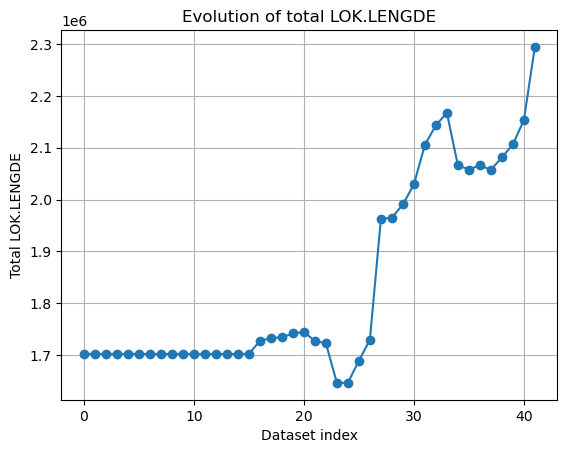

In [32]:
sum_lengths = [df["LOK.LENGDE"].sum() for df in data_all_year]


plt.plot(sum_lengths, marker="o")

plt.xlabel("Dataset index")
plt.ylabel("Total LOK.LENGDE")
plt.title("Evolution of total LOK.LENGDE")

plt.grid(True)
plt.show()

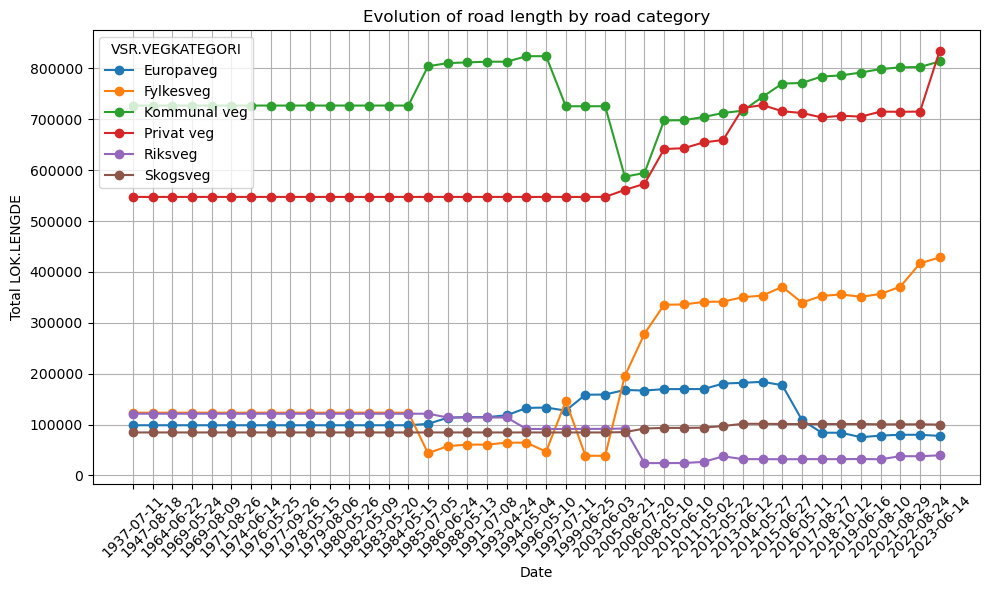

In [34]:
records = []

for df, date in zip(data_all_year, list_date):

    # somme des longueurs par type
    grouped = df.groupby("VSR.VEGKATEGORI")["LOK.LENGDE"].sum()

    for vegtype, length in grouped.items():
        records.append({
            "date": date,
            "type": vegtype,
            "length": length
        })

# créer dataframe résumé
summary = pd.DataFrame(records)

# pivot pour avoir types = colonnes
pivot = summary.pivot(index="date", columns="type", values="length")

# tracer
plt.figure(figsize=(10,6))

for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=col)

plt.xlabel("Date")
plt.ylabel("Total LOK.LENGDE")
plt.title("Evolution of road length by road category")

plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="VSR.VEGKATEGORI")

plt.tight_layout()
plt.show()

## Information on the lifetime of the roads

We will first gather the information in a single dataset.

In [80]:
general_dataset = pd.concat(data_all_year, ignore_index=True)
general_dataset.shape

(387107, 41)

And we only keep objects that are enkelBilveg

In [81]:
general_dataset = general_dataset[general_dataset["LOK.TYPEVEG"] == "enkelBilveg"]
general_dataset["OBJ.STARTDATO"] = pd.to_datetime(
    general_dataset["OBJ.STARTDATO"], errors="coerce"
)

general_dataset["OBJ.SLUTTDATO"] = pd.to_datetime(
    general_dataset["OBJ.SLUTTDATO"], errors="coerce"
)
# Convert road length to numeric
general_dataset["LOK.LENGDE"] = pd.to_numeric(
    general_dataset["LOK.LENGDE"], errors="coerce"
)
general_dataset.shape

(280846, 41)

In [82]:
general_dataset_objid = general_dataset.drop_duplicates(subset=["OBJ.VEGOBJEKT-ID"])
general_dataset_objid.shape

(19376, 41)

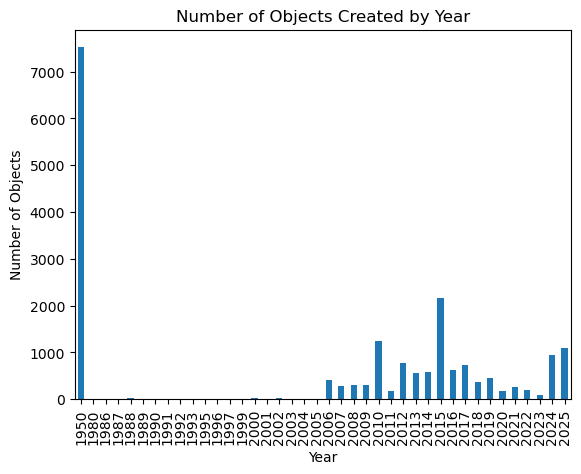

In [83]:
counts_construction = general_dataset_objid.groupby(
    general_dataset_objid["OBJ.STARTDATO"].dt.year
).size()

counts_construction.plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Number of Objects")
plt.title("Number of Objects Created by Year")

plt.show()


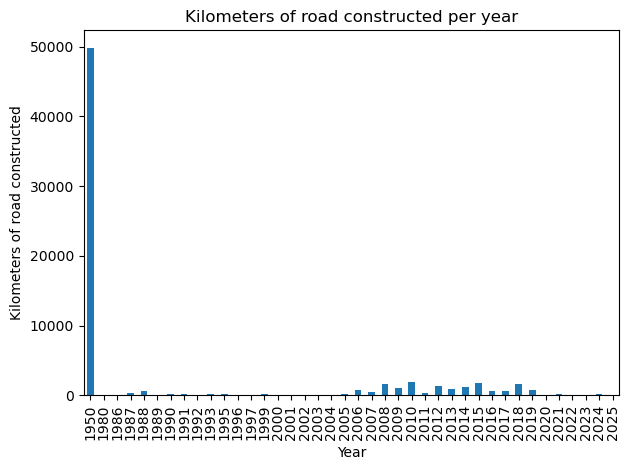

In [85]:
# Sum road length per construction year
km_construction = (
    general_dataset
    .groupby(general_dataset["OBJ.STARTDATO"].dt.year)["LOK.LENGDE"]
    .sum()
    / 1000
)

# Plot
km_construction.plot(kind="bar")
plt.xlabel("Year")
plt.ylabel("Kilometers of road constructed")
plt.title("Kilometers of road constructed per year")
plt.tight_layout()
plt.show()

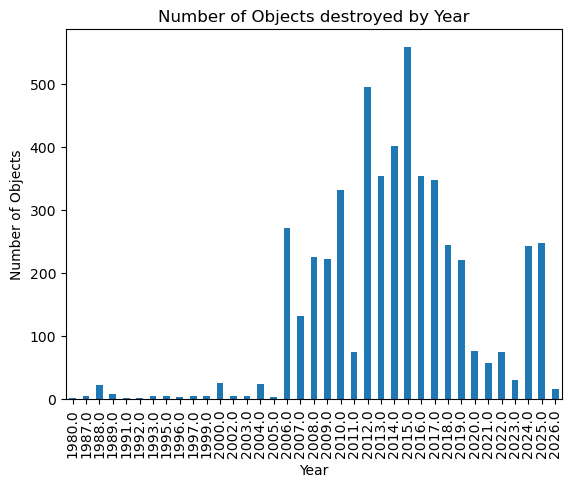

In [86]:
general_dataset_objid_datetime_slutt = pd.to_datetime(general_dataset_objid["OBJ.SLUTTDATO"])
counts = general_dataset_objid_datetime_slutt.groupby(general_dataset_objid_datetime_slutt.dt.year).size()
counts.plot(kind="bar")
plt.xlabel("Year")
plt.ylabel("Number of Objects")
plt.title("Number of Objects destroyed by Year")
plt.show()

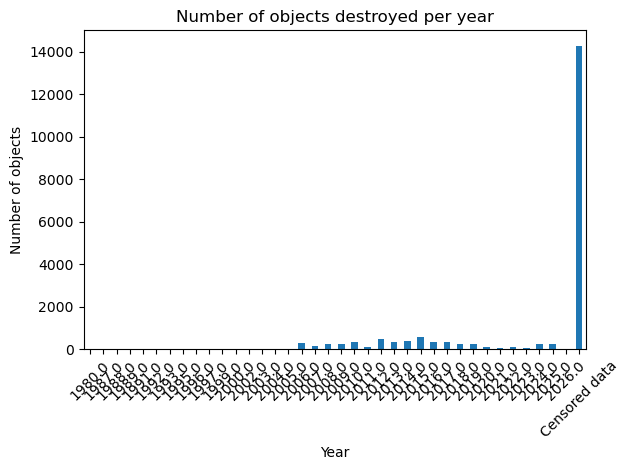

In [87]:
general_dataset_objid_datetime_slutt = pd.to_datetime(general_dataset_objid["OBJ.SLUTTDATO"])
counts_destruction = general_dataset_objid_datetime_slutt.groupby(general_dataset_objid_datetime_slutt.dt.year).size()

# Count censored data (start date exists but no end date)
censored_count = general_dataset_objid[
    general_dataset_objid["OBJ.STARTDATO"].notna() & general_dataset_objid["OBJ.SLUTTDATO"].isna()
].shape[0]

# Add the censoring value as a new category
counts_destruction["Censored data"] = censored_count

# Plot
counts_destruction.plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Number of objects")
plt.title("Number of objects destroyed per year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

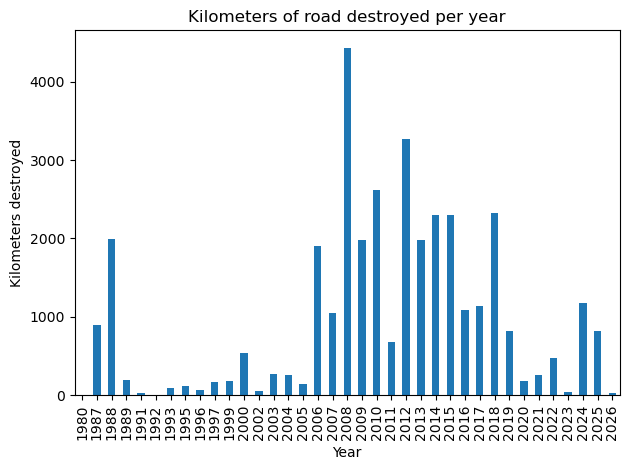

In [88]:
# Keep only rows where a destruction date exists
df_destroyed = general_dataset.dropna(subset=["OBJ.SLUTTDATO"]).copy()

# Sum road length per destruction year
km_destroyed = (
    df_destroyed
    .groupby(df_destroyed["OBJ.SLUTTDATO"].dt.year)["LOK.LENGDE"]
    .sum() / 1000   # convert meters → km if needed
)

# Plot
km_destroyed.plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Kilometers destroyed")
plt.title("Kilometers of road destroyed per year")
plt.tight_layout()

plt.show()

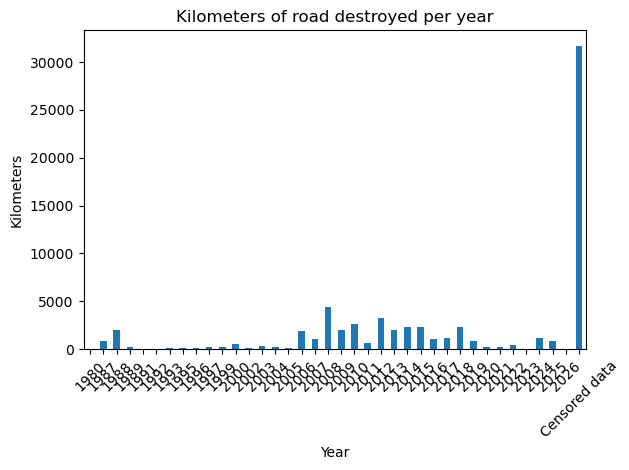

In [89]:
# Compute km censored (roads with start date but no end date)
km_censored = (
    general_dataset[
        general_dataset["OBJ.STARTDATO"].notna() &
        general_dataset["OBJ.SLUTTDATO"].isna()
    ]["LOK.LENGDE"]
    .sum() / 1000
)

# Add censored data as a new bar
km_destroyed["Censored data"] = km_censored

# Plot
km_destroyed.plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Kilometers")
plt.title("Kilometers of road destroyed per year")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

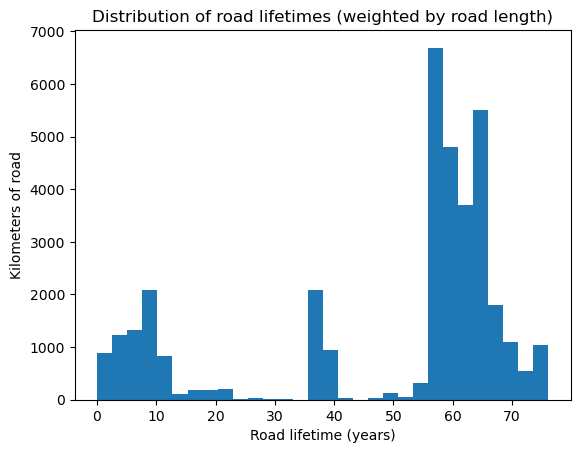

In [90]:
# Keep only rows with both start and end dates
df_lifetime = general_dataset.dropna(subset=["OBJ.STARTDATO", "OBJ.SLUTTDATO"]).copy()

# Convert columns
df_lifetime["OBJ.STARTDATO"] = pd.to_datetime(df_lifetime["OBJ.STARTDATO"], errors="coerce")
df_lifetime["OBJ.SLUTTDATO"] = pd.to_datetime(df_lifetime["OBJ.SLUTTDATO"], errors="coerce")
df_lifetime["LOK.LENGDE"] = pd.to_numeric(df_lifetime["LOK.LENGDE"], errors="coerce")

# Compute lifetime
df_lifetime["lifetime_days"] = (
    df_lifetime["OBJ.SLUTTDATO"] - df_lifetime["OBJ.STARTDATO"]
).dt.days

df_lifetime["lifetime_years"] = df_lifetime["lifetime_days"] / 365.25

# Convert length to km if needed
df_lifetime["length_km"] = df_lifetime["LOK.LENGDE"] / 1000

# Plot weighted histogram
plt.figure()

plt.hist(
    df_lifetime["lifetime_years"],
    bins=30,
    weights=df_lifetime["length_km"]
)

plt.xlabel("Road lifetime (years)")
plt.ylabel("Kilometers of road")
plt.title("Distribution of road lifetimes (weighted by road length)")

plt.show()

c:\Users\leoli\miniconda3\envs\TEP4221\Lib\site-packages\lifelines\fitters\kaplan_meier_fitter.py:338: StatisticalWarning: It looks like your weights are not integers, possibly propensity scores then?
  It's important to know that the naive variance estimates of the coefficients are biased. Instead use Monte Carlo to
  estimate the variances. See paper "Variance estimation when using inverse probability of treatment weighting (IPTW) with survival analysis"
  or "Adjusted Kaplan-Meier estimator and log-rank test with inverse probability of treatment weighting for survival data."
                  
  warnings.warn(


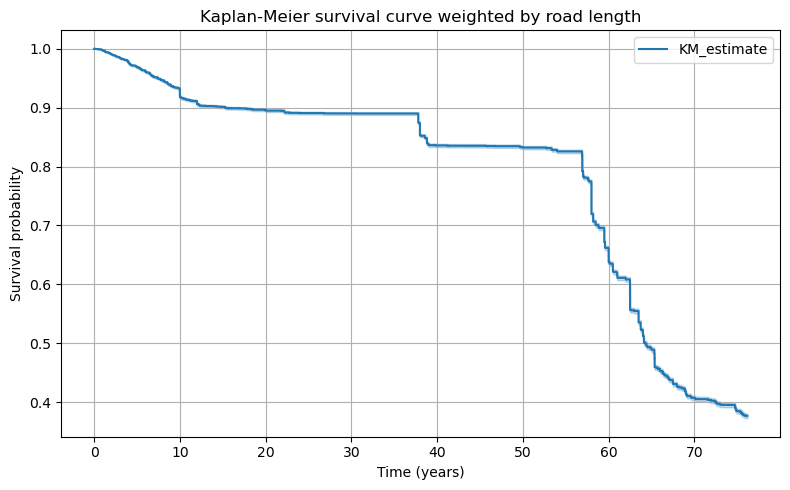

In [91]:
# Copy dataframe
df_lifetime_KM = general_dataset.copy()

# Convert dates
df_lifetime_KM["OBJ.STARTDATO"] = pd.to_datetime(df_lifetime_KM["OBJ.STARTDATO"], errors="coerce")
df_lifetime_KM["OBJ.SLUTTDATO"] = pd.to_datetime(df_lifetime_KM["OBJ.SLUTTDATO"], errors="coerce")

# Convert road length to numeric
df_lifetime_KM["LOK.LENGDE"] = pd.to_numeric(df_lifetime_KM["LOK.LENGDE"], errors="coerce")

# Keep only rows with a valid start date and valid length
df_lifetime_KM = df_lifetime_KM.dropna(subset=["OBJ.STARTDATO", "LOK.LENGDE"]).copy()
df_lifetime_KM = df_lifetime_KM[df_lifetime_KM["LOK.LENGDE"] > 0].copy()

# Create event indicator:
# True = road has an end date (destroyed)
# False = road is censored (still existing / no end date)
df_lifetime_KM["event"] = df_lifetime_KM["OBJ.SLUTTDATO"].notna()

# Use today's date for censored observations
today = pd.Timestamp.today().normalize()

# Compute duration in years
df_lifetime_KM["duration"] = (
    df_lifetime_KM["OBJ.SLUTTDATO"].fillna(today) - df_lifetime_KM["OBJ.STARTDATO"]
).dt.days / 365.25

# Remove rows with missing or invalid duration
df_lifetime_KM = df_lifetime_KM.dropna(subset=["duration"]).copy()
df_lifetime_KM = df_lifetime_KM[df_lifetime_KM["duration"] >= 0].copy()

# Create weight column in kilometers
df_lifetime_KM["weight_km"] = df_lifetime_KM["LOK.LENGDE"] / 1000

# Fit weighted Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(
    durations=df_lifetime_KM["duration"],
    event_observed=df_lifetime_KM["event"],
    weights=df_lifetime_KM["weight_km"]
)

# Plot
plt.figure(figsize=(8, 5))
kmf.plot_survival_function(ci_show=True)

plt.xlabel("Time (years)")
plt.ylabel("Survival probability")
plt.title("Kaplan-Meier survival curve weighted by road length")
plt.grid(True)
plt.tight_layout()
plt.show()

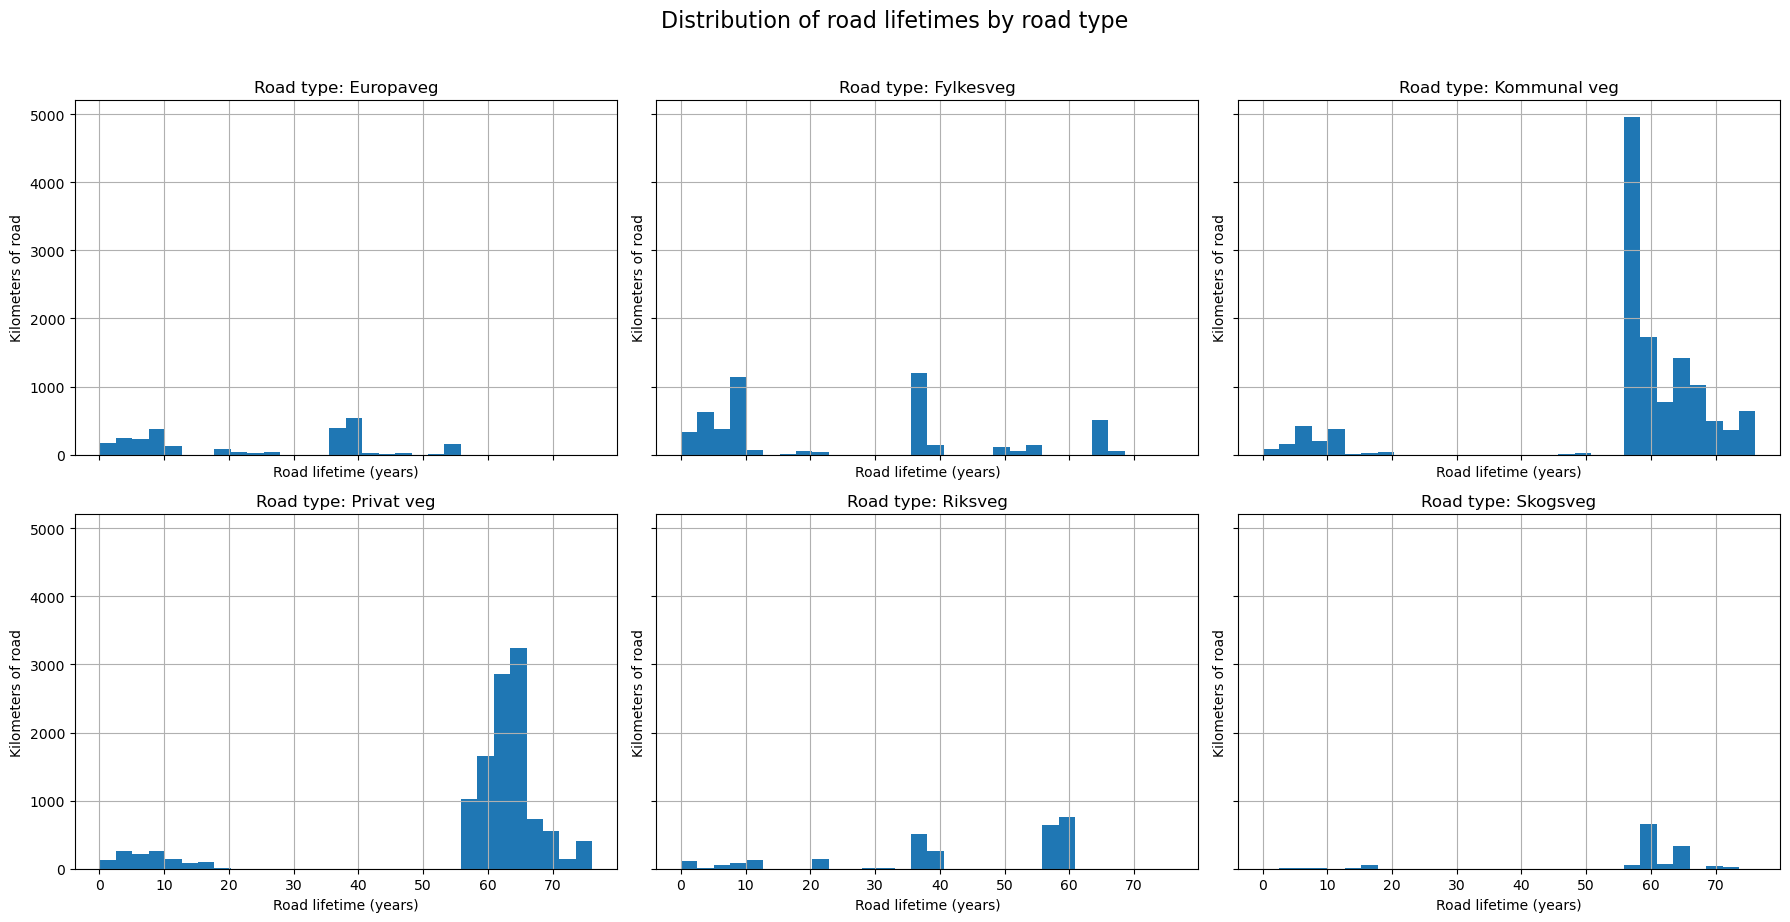

In [92]:
# Copy dataframe
df_lifetime = general_dataset.copy()

# Keep only rows with both start and end dates and a road type
df_lifetime = df_lifetime.dropna(
    subset=["OBJ.STARTDATO", "OBJ.SLUTTDATO", "VSR.VEGKATEGORI", "LOK.LENGDE"]
).copy()

# Convert columns
df_lifetime["OBJ.STARTDATO"] = pd.to_datetime(df_lifetime["OBJ.STARTDATO"], errors="coerce")
df_lifetime["OBJ.SLUTTDATO"] = pd.to_datetime(df_lifetime["OBJ.SLUTTDATO"], errors="coerce")
df_lifetime["LOK.LENGDE"] = pd.to_numeric(df_lifetime["LOK.LENGDE"], errors="coerce")

# Remove rows with invalid length
df_lifetime = df_lifetime[df_lifetime["LOK.LENGDE"] > 0].copy()

# Compute lifetime
df_lifetime["lifetime_days"] = (
    df_lifetime["OBJ.SLUTTDATO"] - df_lifetime["OBJ.STARTDATO"]
).dt.days

df_lifetime["lifetime_years"] = df_lifetime["lifetime_days"] / 365.25

# Remove invalid lifetimes
df_lifetime = df_lifetime.dropna(subset=["lifetime_years"]).copy()
df_lifetime = df_lifetime[df_lifetime["lifetime_years"] >= 0].copy()

# Convert length to km
df_lifetime["length_km"] = df_lifetime["LOK.LENGDE"] / 1000

# Get road types
road_types = sorted(df_lifetime["VSR.VEGKATEGORI"].unique())

# Define subplot grid
n_types = len(road_types)
n_cols = 3
n_rows = m.ceil(n_types / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# Common bin edges for all plots
max_lifetime = df_lifetime["lifetime_years"].max()
bins = 30
bin_edges = pd.interval_range(start=0, end=max_lifetime, periods=bins).left.tolist() + [max_lifetime]

# Plot one histogram per road type
for i, road_type in enumerate(road_types):
    ax = axes[i]
    subset = df_lifetime[df_lifetime["VSR.VEGKATEGORI"] == road_type]

    if subset.empty:
        ax.set_visible(False)
        continue

    ax.hist(
        subset["lifetime_years"],
        bins=bin_edges,
        weights=subset["length_km"]
    )

    ax.set_title(f"Road type: {road_type}")
    ax.set_xlabel("Road lifetime (years)")
    ax.set_ylabel("Kilometers of road")
    ax.grid(True)

# Hide unused subplots
for j in range(len(road_types), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of road lifetimes by road type", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

c:\Users\leoli\miniconda3\envs\TEP4221\Lib\site-packages\lifelines\fitters\kaplan_meier_fitter.py:338: StatisticalWarning: It looks like your weights are not integers, possibly propensity scores then?
  It's important to know that the naive variance estimates of the coefficients are biased. Instead use Monte Carlo to
  estimate the variances. See paper "Variance estimation when using inverse probability of treatment weighting (IPTW) with survival analysis"
  or "Adjusted Kaplan-Meier estimator and log-rank test with inverse probability of treatment weighting for survival data."
                  
  warnings.warn(
c:\Users\leoli\miniconda3\envs\TEP4221\Lib\site-packages\lifelines\fitters\kaplan_meier_fitter.py:338: StatisticalWarning: It looks like your weights are not integers, possibly propensity scores then?
  It's important to know that the naive variance estimates of the coefficients are biased. Instead use Monte Carlo to
  estimate the variances. See paper "Variance estimation whe

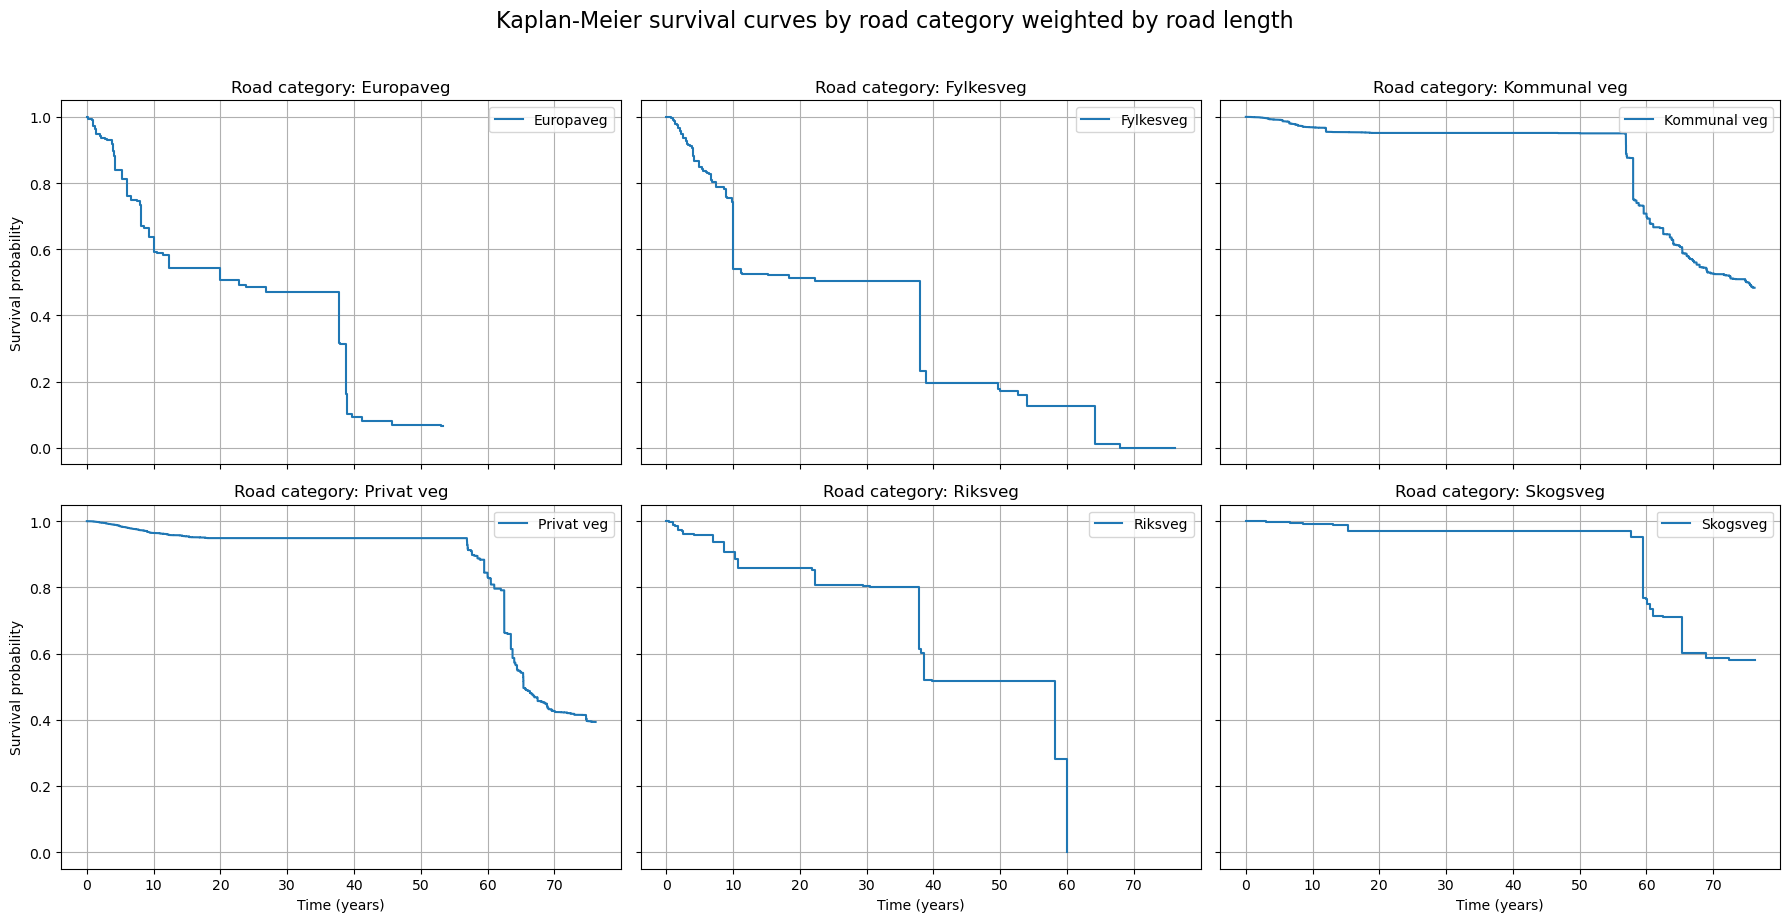

In [94]:
# Copy dataframe
df_km = general_dataset.copy()

# Convert columns
df_km["OBJ.STARTDATO"] = pd.to_datetime(df_km["OBJ.STARTDATO"], errors="coerce")
df_km["OBJ.SLUTTDATO"] = pd.to_datetime(df_km["OBJ.SLUTTDATO"], errors="coerce")
df_km["LOK.LENGDE"] = pd.to_numeric(df_km["LOK.LENGDE"], errors="coerce")

# Keep only rows with valid start date and road category
df_km = df_km.dropna(subset=["OBJ.STARTDATO", "VSR.VEGKATEGORI"]).copy()

# Event indicator: True if road has an end date, False if censored
df_km["event"] = df_km["OBJ.SLUTTDATO"].notna().astype(int)

# Use today's date for censored observations
today = pd.Timestamp.today().normalize()

# Compute duration in years
df_km["duration"] = (
    df_km["OBJ.SLUTTDATO"].fillna(today) - df_km["OBJ.STARTDATO"]
).dt.days / 365.25

# Remove invalid rows
df_km = df_km.dropna(subset=["duration"]).copy()
df_km = df_km[df_km["duration"] >= 0].copy()

# Optional: keep only positive lengths if you want a length-weighted KM
df_km = df_km.dropna(subset=["LOK.LENGDE"]).copy()
df_km = df_km[df_km["LOK.LENGDE"] > 0].copy()

# Get unique road categories
road_categories = sorted(df_km["VSR.VEGKATEGORI"].dropna().unique())

# Define subplot grid size
n_categories = len(road_categories)
n_cols = 3
n_rows = m.ceil(n_categories / n_cols)

# Create subplot matrix
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

# Fit and plot one KM curve per road category
for i, category in enumerate(road_categories):
    ax = axes[i]
    subset = df_km[df_km["VSR.VEGKATEGORI"] == category].copy()

    if len(subset) == 0:
        ax.set_visible(False)
        continue

    kmf = KaplanMeierFitter()

    kmf.fit(
        durations=subset["duration"],
        event_observed=subset["event"],
        weights=subset["LOK.LENGDE"],   
        label=str(category)
    )

    kmf.plot_survival_function(ax=ax, ci_show=False)

    ax.set_title(f"Road category: {category}")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Survival probability")
    ax.grid(True)

# Hide unused subplots
for j in range(len(road_categories), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Kaplan-Meier survival curves by road category weighted by road length", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()